# ACDC Pathology Classification with DINOv3 Logistic Regression Probe

This notebook implements the DINOv3 paper's **logistic regression evaluation protocol**
(Fine-S style) for patient-level pathology classification on the ACDC cardiac MRI dataset.

**Task**: Classify each patient into one of 5 cardiac pathologies:
NOR (Normal), DCM (Dilated Cardiomyopathy), HCM (Hypertrophic Cardiomyopathy),
MINF (Myocardial Infarction), RV (Right Ventricular Cardiomyopathy).

**Protocol** (following DINOv3 Fine-S evaluation):
1. Extract the **CLS token** from the final layer of a frozen DINOv3 backbone for each 2D slice
2. **Pool per patient**: mean-pool ED slices, mean-pool ES slices, concatenate → `(2 × embed_dim,)` feature
3. **C-sweep**: Train sklearn `LogisticRegression` (L-BFGS, L2 penalty) for 45 C values on validation set
4. **Retrain** final model on train+val with best C, evaluate on held-out test set

**Development backbone**: `dinov3_vits16` (~21M params) — lightweight for MacBook Pro.
Swap `MODEL_NAME` to `dinov3_vitb16` or `dinov3_vitl16` for larger backbones.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from monai.transforms import ScaleIntensityd

from heartfm_evals.classification_probe import (
    C_POWER_RANGE,
    NUM_PATHOLOGIES,
    PATHOLOGY_CLASSES,
    PATHOLOGY_NAMES,
    build_patient_features,
    evaluate_classification,
    extract_cls_features,
    get_pathology_map,
    sweep_C_and_train,
)
from heartfm_evals.dense_linear_probe import MODEL_CONFIGS

In [2]:
# ── Paths ──
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc")
REPO_DIR = "../models/dinov3/"

# ── Backbone selection (change here to swap) ──
MODEL_NAME = "dinov3_vits16"  # lightweight for dev; swap to dinov3_vitb16/vitl16
WEIGHTS_PATH = f"../model_weights/{MODEL_NAME}.pth"
EMBED_DIM = MODEL_CONFIGS[MODEL_NAME]["embed_dim"]  # 384 for vits16

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"Backbone: {MODEL_NAME} (embed_dim={EMBED_DIM})")
print(f"Patient feature dim: {2 * EMBED_DIM} (ED-mean ⊕ ES-mean)")

Using device: mps
Backbone: dinov3_vits16 (embed_dim=384)
Patient feature dim: 768 (ED-mean ⊕ ES-mean)


## 2. Load ACDC Metadata

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

print(f"Training set: {len(train_meta_df)} patients")
print(f"Test set:     {len(test_meta_df)} patients")
print(f"\nPathology distribution (train):\n{train_meta_df['pathology'].value_counts().to_string()}")
print(f"\nPathology distribution (test):\n{test_meta_df['pathology'].value_counts().to_string()}")

Training set: 100 patients
Test set:     50 patients

Pathology distribution (train):
pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20

Pathology distribution (test):
pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10


## 3. Train / Validation Split

Stratified by pathology: 2 patients per class held out for validation
(10 val / 90 train), matching the dense segmentation notebook.

In [4]:
val_pids = (
    train_meta_df.groupby("pathology")
    .sample(n=2, random_state=0)["pid"]
    .tolist()
)

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")
print(f"\nVal patient IDs: {val_pids}")
print(f"\nVal pathology distribution:\n{val_split_df['pathology'].value_counts().to_string()}")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients

Val patient IDs: ['patient019', 'patient002', 'patient032', 'patient022', 'patient056', 'patient054', 'patient079', 'patient061', 'patient088', 'patient082']

Val pathology distribution:
pathology
DCM     2
HCM     2
MINF    2
NOR     2
RV      2


## 4. Create CineMA Datasets

In [5]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples (ED+ES volumes)")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples (ED+ES volumes)
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


## 5. Load Backbone

The backbone is frozen — we only use it to extract CLS token features.

In [6]:
backbone = torch.hub.load(REPO_DIR, MODEL_NAME, source="local", weights=WEIGHTS_PATH)
backbone.eval()
backbone.to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False
print(f"Loaded {MODEL_NAME} with {sum(p.numel() for p in backbone.parameters()):,} parameters (frozen)")

Loaded dinov3_vits16 with 21,601,152 parameters (frozen)


## 6. Extract CLS Features

For each split, extract the final-layer CLS token for every 2D slice,
grouped by patient and cardiac phase (ED/ES).

In [7]:
print("Extracting training features...")
train_cls = extract_cls_features(backbone, train_cinema, device=DEVICE)

print("\nExtracting validation features...")
val_cls = extract_cls_features(backbone, val_cinema, device=DEVICE)

print("\nExtracting test features...")
test_cls = extract_cls_features(backbone, test_cinema, device=DEVICE)

print(f"\nExtracted features for {len(train_cls)} train, {len(val_cls)} val, {len(test_cls)} test patients")

# Verify shapes
sample_pid = next(iter(train_cls))
print(f"\nSample patient '{sample_pid}':")
print(f"  ED features: {train_cls[sample_pid]['ed_features'].shape}")
print(f"  ES features: {train_cls[sample_pid]['es_features'].shape}")

Extracting training features...


Extracting CLS features: 100%|██████████| 180/180 [00:30<00:00,  5.89it/s]



Extracting validation features...


Extracting CLS features: 100%|██████████| 20/20 [00:03<00:00,  5.84it/s]



Extracting test features...


Extracting CLS features: 100%|██████████| 100/100 [00:17<00:00,  5.76it/s]


Extracted features for 90 train, 10 val, 50 test patients

Sample patient 'patient001':
  ED features: torch.Size([10, 384])
  ES features: torch.Size([10, 384])


## 7. Build Patient-Level Features

Mean-pool ED CLS tokens + mean-pool ES CLS tokens, then concatenate
to form a `(2 × embed_dim,)` feature vector per patient.

In [8]:
# Pathology maps from metadata
train_pathology_map = get_pathology_map(train_split_df)
val_pathology_map   = get_pathology_map(val_split_df)
test_pathology_map  = get_pathology_map(test_meta_df)

train_features, train_labels, train_pids = build_patient_features(train_cls, train_pathology_map)
val_features, val_labels, val_pids_list  = build_patient_features(val_cls, val_pathology_map)
test_features, test_labels, test_pids    = build_patient_features(test_cls, test_pathology_map)

print(f"Train features: {train_features.shape} (dtype={train_features.dtype})")
print(f"Val features:   {val_features.shape}")
print(f"Test features:  {test_features.shape}")

expected_dim = 2 * EMBED_DIM
assert train_features.shape[1] == expected_dim, f"Expected {expected_dim}, got {train_features.shape[1]}"
print(f"\nFeature dim check passed: {expected_dim}")

# Label distribution
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = {PATHOLOGY_NAMES[i]: (labels == i).sum().item() for i in range(NUM_PATHOLOGIES)}
    print(f"{split_name} label distribution: {counts}")

Train features: torch.Size([90, 768]) (dtype=torch.float64)
Val features:   torch.Size([10, 768])
Test features:  torch.Size([50, 768])

Feature dim check passed: 768
Train label distribution: {'NOR': 18, 'DCM': 18, 'HCM': 18, 'MINF': 18, 'RV': 18}
Val label distribution: {'NOR': 2, 'DCM': 2, 'HCM': 2, 'MINF': 2, 'RV': 2}
Test label distribution: {'NOR': 10, 'DCM': 10, 'HCM': 10, 'MINF': 10, 'RV': 10}


## 8. C-Sweep and Training

Sweep 45 regularisation strengths C = 10^k for k ∈ [-6, 5],
pick best on validation accuracy, retrain on train+val.

In [10]:
best_C, final_model, sweep_results = sweep_C_and_train(
    train_features, train_labels,
    val_features, val_labels,
)

print(f"\nBest C = {best_C:.4g}")
print(f"Best val accuracy = {max(r['val_acc'] for r in sweep_results):.4f}")

C-sweep:   0%|          | 0/45 [00:00<?, ?it/s]/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-pa


Best C = 562.3
Best val accuracy = 0.5000



/Users/lbokeria/projects/health_gc/heartfm-evals/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### C-Sweep Curve

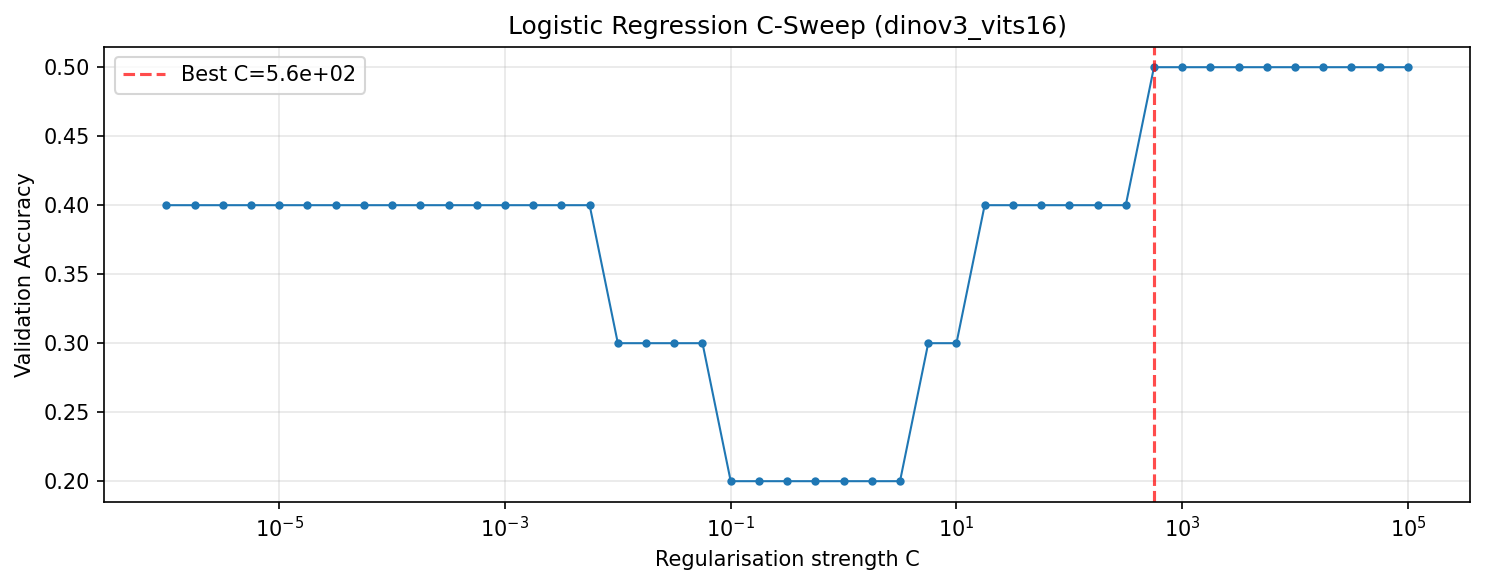

In [11]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

c_values = [r["C"] for r in sweep_results]
val_accs = [r["val_acc"] for r in sweep_results]

ax.semilogx(c_values, val_accs, "o-", markersize=3, linewidth=1)
ax.axvline(best_C, color="red", linestyle="--", alpha=0.7, label=f"Best C={best_C:.2g}")
ax.set_xlabel("Regularisation strength C")
ax.set_ylabel("Validation Accuracy")
ax.set_title(f"Logistic Regression C-Sweep ({MODEL_NAME})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [12]:
test_metrics = evaluate_classification(final_model, test_features, test_labels)

print(f"Test Top-1 Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:       {test_metrics['macro_f1']:.4f}")
print(f"\nPer-class accuracy:")
for cls, acc in test_metrics["per_class_accuracy"].items():
    print(f"  {cls:>4s}: {acc:.4f}")

Test Top-1 Accuracy: 0.5000
Test Macro F1:       0.4974

Per-class accuracy:
   NOR: 0.3000
   DCM: 0.5000
   HCM: 0.4000
  MINF: 0.6000
    RV: 0.7000


### Confusion Matrix

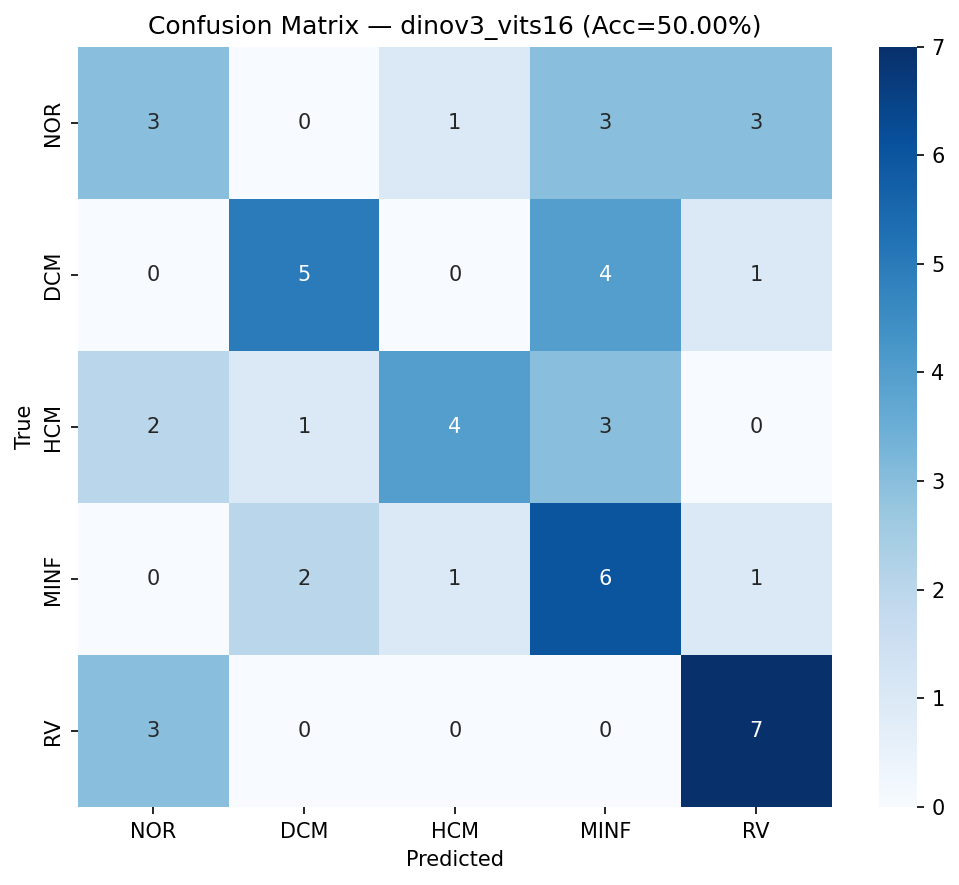

In [13]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

class_names = list(PATHOLOGY_CLASSES.keys())
cm = test_metrics["confusion_matrix"]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {MODEL_NAME} (Acc={test_metrics['accuracy']:.2%})")
plt.tight_layout()
plt.show()

### Classification Report

In [14]:
report_df = pd.DataFrame(test_metrics["classification_report"]).T
display(report_df.round(3))

,precision,recall,f1-score,support
NOR,0.375,0.3,0.333,10.0
DCM,0.625,0.5,0.556,10.0
HCM,0.667,0.4,0.500,10.0
MINF,0.375,0.6,0.462,10.0
RV,0.583,0.7,0.636,10.0
accuracy,0.500,0.5,0.500,0.5
macro avg,0.525,0.5,0.497,50.0
weighted avg,0.525,0.5,0.497,50.0


## 10. Per-Patient Results

In [15]:
results_df = pd.DataFrame({
    "pid": test_pids,
    "true_label": [PATHOLOGY_NAMES[l.item()] for l in test_labels],
    "predicted": [PATHOLOGY_NAMES[p] for p in test_metrics["predictions"]],
})
results_df["correct"] = results_df["true_label"] == results_df["predicted"]

print(f"Correct: {results_df['correct'].sum()} / {len(results_df)}")
print(f"\nMisclassified patients:")
display(results_df[~results_df["correct"]])

Correct: 25 / 50

Misclassified patients:


,pid,true_label,predicted,correct
0,patient101,DCM,MINF,False
1,patient102,NOR,HCM,False
5,patient106,DCM,RV,False
6,patient107,NOR,MINF,False
8,patient109,RV,NOR,False
9,patient110,NOR,MINF,False
10,patient111,HCM,NOR,False
12,patient113,DCM,MINF,False
13,patient114,HCM,MINF,False
14,patient115,MINF,RV,False


## 11. Summary

In [16]:
print("=" * 60)
print(f"ACDC Pathology Classification — Logistic Regression Probe")
print("=" * 60)
print(f"Backbone:          {MODEL_NAME} (embed_dim={EMBED_DIM})")
print(f"Feature type:      Final-layer CLS token")
print(f"Pooling:           ED-mean ⊕ ES-mean → ({2*EMBED_DIM},)")
print(f"Classifier:        sklearn LogisticRegression (L-BFGS, L2)")
print(f"Best C:            {best_C:.4g}")
print(f"Train patients:    {len(train_pids)}")
print(f"Val patients:      {len(val_pids_list)}")
print(f"Test patients:     {len(test_pids)}")
print(f"─" * 60)
print(f"Test Accuracy:     {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:     {test_metrics['macro_f1']:.4f}")
print("=" * 60)

ACDC Pathology Classification — Logistic Regression Probe
Backbone:          dinov3_vits16 (embed_dim=384)
Feature type:      Final-layer CLS token
Pooling:           ED-mean ⊕ ES-mean → (768,)
Classifier:        sklearn LogisticRegression (L-BFGS, L2)
Best C:            562.3
Train patients:    90
Val patients:      10
Test patients:     50
────────────────────────────────────────────────────────────
Test Accuracy:     0.5000
Test Macro F1:     0.4974
